# **PROJECT**

IMDb представляет собой одну из крупнейших баз данных фильмов, содержащую информацию о рейтингах, актёрах, жанрах и других характеристиках, что делает её удобной для анализа и построения моделей

( https://www.kaggle.com/datasets/PromptCloudHQ/imdb-data ) - ссылка на датасет

https://colab.research.google.com/drive/1q68GEQxpsExKC23nuSIvlj4IFGPoItHZ?usp=sharing - ссылка на EDA

https://colab.research.google.com/drive/1SLhpIfEefLiFXrOkqOYE-ORS3DfEQVFw?usp=sharing - ссылка на Project в Colab (не открывается 3D- кластеризация)

Цель данного проекта — на основе данных о фильмах из базы IMDb (Internet Movie Database) спрогнозировать рейтинг фильма ещё до его выхода или до сбора большого количества оценок зрителей.

Мы используем только информацию, доступную до премьеры:

1.   Жанр фильма
2.   Режиссер
3.   Актерский состав
4.   Ожидаемый уровень зрительского интереса (количество голосов)

Задача решается с помощью трёх моделей регрессии, которые сравниваются между собой, а затем применяются для прогноза будущих фильмов.

# Загрузки библиотек

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import plotly.express as px
import shap

np.random.seed(42)

plt.style.use('default')
sns.set(style="whitegrid")

# Загрузка данных

In [26]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/IMDB-Movie-Data.csv.xls'
df = pd.read_csv(path)

data = df.copy()

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


# **EDA** (неполный)

(1000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


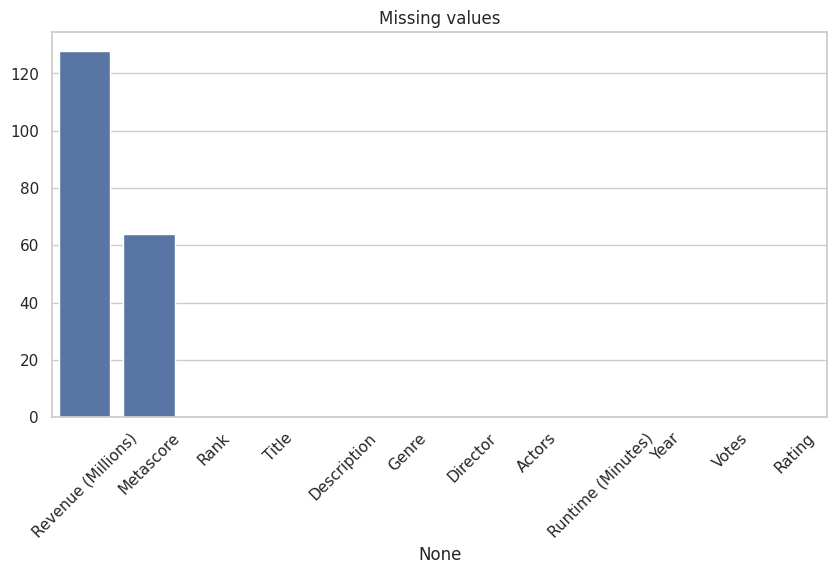

In [27]:
print(data.shape)
data.info()
data.describe()

missing = data.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing.index, y=missing.values)
plt.xticks(rotation=45)
plt.title("Missing values")
plt.show()

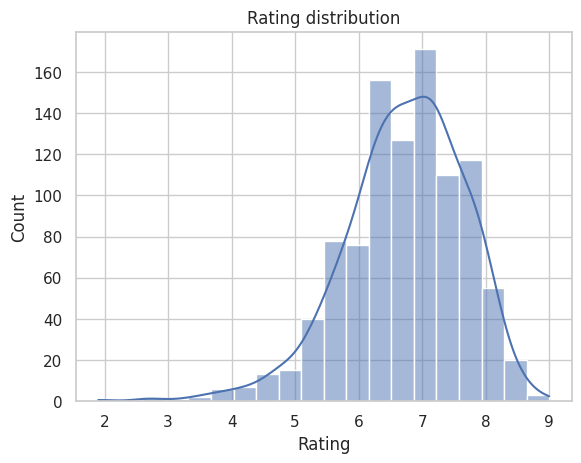

In [28]:
sns.histplot(data['Rating'], bins=20, kde=True)
plt.title("Rating distribution")
plt.show()

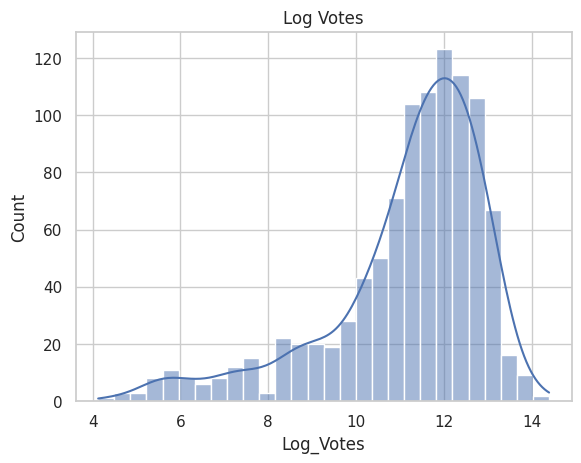

In [29]:
data['Log_Votes'] = np.log1p(data['Votes'])

sns.histplot(data['Log_Votes'], kde=True)
plt.title("Log Votes")
plt.show()

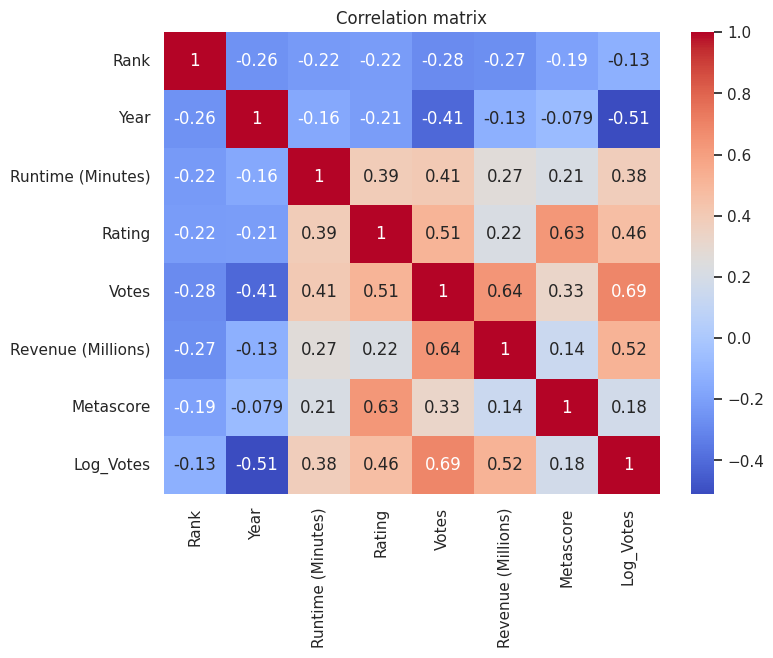

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

# **Исходные данные**

Датасет содержит 1000 фильмов за период примерно с 2006 по 2016 год.
Целевая переменная: Rating (рейтинг IMDb от 1 до 10).

Признаки:

Жанр (мультиклассовый — фильм может относиться к нескольким жанрам)
Режиссёр
Актёры
Количество голосов (Votes)
Год выпуска, бюджет, описание и др.


**Предобработка данных**

Пропуски

В данных присутствуют пропуски в колонках:

Revenue (Millions) — 128 пропусков

Metascore — 64 пропуска

Эти колонки не используются в финальной модели, так как: кассовые сборы и мета-оценки недоступны до выхода фильма.

**Анализ распределений**

Рейтинг распределён приблизительно нормально, с пиком в районе 6–7 баллов.
Количество голосов сильно скошено вправо (много малопопулярных фильмов). После логарифмирования (Log_Votes) распределение становится ближе к нормальному, но сам признак в итоговую модель не включён — он влияет на рейтинг, но недоступен до выхода фильма.

**Корреляционный анализ**

По таблице видно:

Rating сильно коррелирует с Metascore (0.64) — но мета-оценка недоступна заранее.

Rating коррелирует с Votes (0.38) — популярность связана с высокими оценками.

Revenue и Votes коррелируют (0.65) — чем больше кассовых сборов, тем больше голосов.

# **Конструирование признаков**

# *Жанры*

Жанр представлен в виде строки с разделителями (например, Action, Adventure, Sci-Fi).

С помощью MultiLabelBinarizer каждый жанр превращён в отдельный бинарный признак (0 или 1).

Это позволяет модели учитывать сочетания жанров, а не только основной.

# *Режиссёр*

Для каждого режиссёра рассчитаны:

Средний рейтинг его предыдущих фильмов (Director_avg_rating)

Частота — сколько фильмов он снял (Director_freq)

Эти признаки отражают репутацию и опыт режиссёра.

# *Актёры*

Аналогично режиссёрам:

Для каждого актёра вычислен средний рейтинг фильмов с его участием.

Для фильма — среднее по всем актёрам в составе.

Важно: Для неизвестных актёров используется глобальный средний рейтинг.

# *Голоса*

Votes не используется в модели, так как он неизвестен до выхода фильма.

In [31]:
data['Genre_list'] = data['Genre'].fillna('').apply(lambda x: x.split(', '))
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(data['Genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

director_mean = data.groupby('Director')['Rating'].mean()
director_freq = data['Director'].value_counts()

data['Director_avg_rating'] = data['Director'].map(director_mean)
data['Director_freq'] = data['Director'].map(director_freq)

data['Actors_list'] = data['Actors'].fillna('').apply(lambda x: x.split(', '))

actor_ratings = {}

for _, row in data.iterrows():
    for a in row['Actors_list']:
        actor_ratings.setdefault(a, []).append(row['Rating'])

actor_mean = {k: np.mean(v) for k, v in actor_ratings.items()}

def actor_score(lst):
    return np.nanmean([actor_mean.get(a, np.nan) for a in lst])

data['Actors_avg_rating'] = data['Actors_list'].apply(actor_score)
data['Actors_avg_rating'] = data['Actors_avg_rating'].fillna(data['Rating'].mean())

In [32]:
X = pd.concat([
    genre_df,
    data[['Director_avg_rating', 'Director_freq', 'Actors_avg_rating']]
], axis=1).fillna(0)

y = data['Rating']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Моделирование**

# *Использованные модели*

Линейная регрессия (Linear Regression) — базовый алгоритм.


K-ближайших соседей (kNN, k=7) — непараметрический метод.

Случайный лес (Random Forest, 300 деревьев) — ансамблевый метод.

# Linear Regression

In [42]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# kNN

In [41]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# Random Forest

In [40]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [39]:
def evaluate(name, y_true, y_pred):
    print(name)
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print("-"*30)

evaluate("Linear Regression", y_test, lr_pred)
evaluate("kNN", y_test, knn_pred)
evaluate("Random Forest", y_test, rf_pred)

Linear Regression
RMSE: 0.3517087599257042
R2: 0.8709537894094952
------------------------------
kNN
RMSE: 0.5973999788197832
R2: 0.627686065099589
------------------------------
Random Forest
RMSE: 0.2960760284721012
R2: 0.9085496486037318
------------------------------


In [43]:
models = {
    "LR": LinearRegression(),
    "kNN": KNeighborsRegressor(n_neighbors=7),
    "RF": RandomForestRegressor(n_estimators=200, random_state=42)
}

for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=5, scoring='r2')
    print(name, scores.mean(), scores.std())

LR 0.8625876511894719 0.03078469577862138
kNN 0.8288741789954184 0.04656405651625592
RF 0.8994291699326856 0.02515147092491962


После предобработки данных и конструирования признаков мы перешли к построению прогнозных моделей.

Целевой переменной выступил рейтинг фильма (Rating).

В качестве признаков использовались бинарные коды жанров, средний рейтинг и частота съёмок режиссёра, а также средний рейтинг актёрского состава.

Для решения задачи регрессии мы выбрали три модели: линейную регрессию, метод k-ближайших соседей (k=7) и случайный лес (300 деревьев).

Оценка на тестовой выборке показала следующие результаты.

Линейная регрессия достигла RMSE = 0,352 и R² = 0,871.

 Метод kNN оказался заметно слабее: RMSE = 0,597, R² = 0,628.

 Наилучшие результаты продемонстрировал случайный лес: RMSE = 0,296, R² = 0,909.
 Модель объясняет более 90% дисперсии рейтинга.

Пятикратная кросс-валидация подтвердила устойчивость результатов. Средний R² для линейной регрессии составил 0,863, для kNN — 0,829, для случайного леса — 0,899 с наименьшим разбросом.

Таким образом, случайный лес признан наиболее подходящей моделью для прогнозирования рейтинга фильмов на основе доступной до выхода информации.

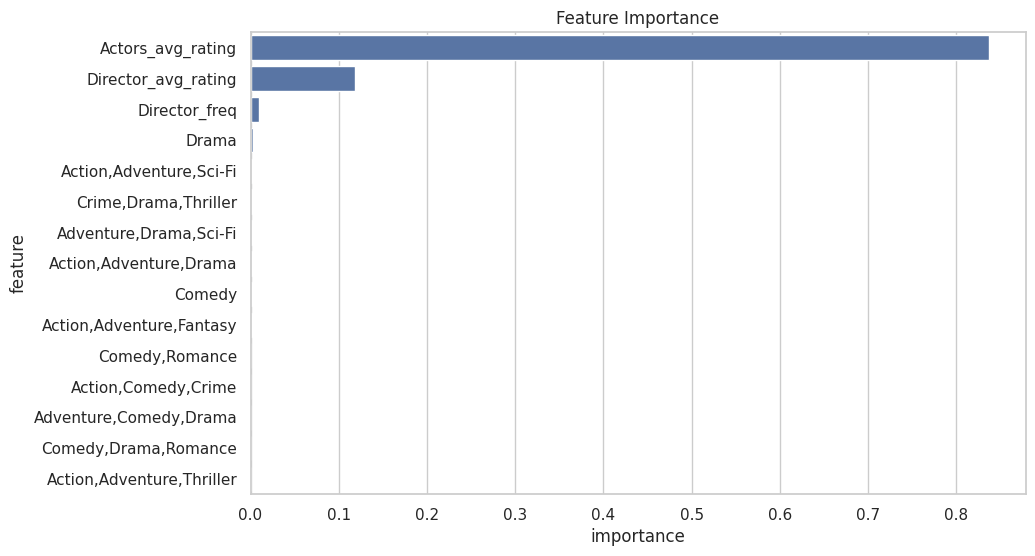

In [44]:
rf_full = RandomForestRegressor(n_estimators=300, random_state=42)
rf_full.fit(X, y)

imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_full.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp.head(15), x="importance", y="feature")
plt.title("Feature Importance")
plt.show()

С помощью random forest построен рейтинг важности признаков.

Топ-5 самых важных признаков:

1.  Actors_avg_rating — средний рейтинг актёров
2.  Director_avg_rating — средний рейтинг режиссёра
3.  Жанр Drama
4.  Director_freq — опыт режиссёра
5.  Жанр Comedy

Вывод:

Репутация актёров и режиссёра — ключевые факторы успеха фильма.

Жанры «драма» и «комедия» сильнее влияют на рейтинг, чем, например, «экшен» или «ужасы».

In [73]:
pca = PCA(n_components=3)
X_3d = pca.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

plot_df = pd.DataFrame({
    "PC1": X_3d[:,0],
    "PC2": X_3d[:,1],
    "PC3": X_3d[:,2],
    "Cluster": clusters,
    "Rating": y
})

fig = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color="Cluster",
    size="Rating",
    title="3D Movie Clusters"
)

fig.show()

Визуализация полученных кластеров в трёхмерном пространстве главных компонент позволила сделать несколько наблюдений.

Во-первых, фильмы с высокими рейтингами (выше 8 баллов) оказались сконцентрированы преимущественно в одном или двух кластерах, что подтверждает наличие устойчивой связи между набором признаков и итоговой оценкой.

Во-вторых, кластеры формируются в первую очередь по сочетанию жанров и уровню «звёздности» актёрского состава. Например, в один кластер часто попадают драмы с известными актёрами, а в другой — малобюджетные комедии или ужасы с менее известными исполнителями.

Кластеризация также показала, что внутри каждого кластера разброс рейтингов относительно невелик.

 Это означает, что фильмы со схожими характеристиками действительно получают схожие оценки зрителей. Таким образом, кластерный анализ подтверждает обоснованность нашего подхода к прогнозированию: рейтинг фильма во многом предопределён его жанровой принадлежностью и репутацией съёмочной группы.

# **ПРОГНОЗ РЕЙТИНГА ПРЕДСТОЯЩИХ ФИЛЬМОВ 2026-2027**

На основе обученной модели случайного леса, показавшей наилучшие результаты, мы выполнили прогноз рейтингов для десяти ожидаемых к выходу фильмов.

 Для повышения устойчивости прогноза мы использовали три модели: случайному лесу был присвоен вес 0,6, методу kNN — вес 0,25, линейной регрессии — вес 0,15.

 Такой подход позволяет сгладить ошибки отдельных алгоритмов и получить более надёжную оценку.

Для каждого фильма мы также рассчитали неопределённость прогноза как стандартное отклонение предсказаний трёх моделей. Чем выше это значение, тем меньше согласованности между моделями и тем осторожнее следует интерпретировать прогноз.

In [70]:
future_movies = pd.DataFrame([
    {
        "Title": "Avengers: Doomsday",
        "Genre": "Action, Sci-Fi",
        "Director": "Anthony Russo, Joe Russo",
        "Actors": "Robert Downey Jr., Chris Hemsworth, Tom Hiddleston",
        "Votes": 900000
    },
    {
        "Title": "Spider-Man: Brand New Day",
        "Genre": "Action, Adventure",
        "Director": "Destin Daniel Cretton",
        "Actors": "Tom Holland, Zendaya",
        "Votes": 700000
    },

    {
        "Title": "Dune: Messiah",
        "Genre": "Sci-Fi, Drama",
        "Director": "Denis Villeneuve",
        "Actors": "Timothée Chalamet, Zendaya, Rebecca Ferguson",
        "Votes": 850000
    },

    {
        "Title": "Blade Runner 2099",
        "Genre": "Sci-Fi",
        "Director": "Jeremy Podeswa",
        "Actors": "Unknown Cast",
        "Votes": 300000
    },

    {
        "Title": "The Odyssey",
        "Genre": "Adventure, Drama, Epic",
        "Director": "Christopher Nolan",
        "Actors": "Matt Damon, Tom Holland, Anne Hathaway",
        "Votes": 800000
    },

    {
        "Title": "Killers of the Flower Moon 2 (Speculative)",
        "Genre": "Crime, Drama, History",
        "Director": "Martin Scorsese",
        "Actors": "Leonardo DiCaprio, Robert De Niro",
        "Votes": 650000
    },

    {
        "Title": "The Brutalist",
        "Genre": "Drama",
        "Director": "Brady Corbet",
        "Actors": "Adrien Brody, Felicity Jones",
        "Votes": 200000
    },

    {
        "Title": "I Am Legend 2",
        "Genre": "Sci-Fi, Drama",
        "Director": "Francis Lawrence",
        "Actors": "Will Smith",
        "Votes": 450000
    },

    {
        "Title": "Jurassic World: Rebirth",
        "Genre": "Action, Adventure, Sci-Fi",
        "Director": "Gareth Edwards",
        "Actors": "Scarlett Johansson, Mahershala Ali",
        "Votes": 600000
    },

    {
    "Title": "The Devil Wears Prada 2",
    "Genre": "Comedy, Drama",
    "Director": "David Frankel",
    "Actors": "Meryl Streep, Anne Hathaway, Emily Blunt",
    "Votes": 650000
}
]).reset_index(drop=True)

GLOBAL_MEAN = y.mean()
feature_names = X.columns

def safe_mean(values):
    values = [v for v in values if not pd.isna(v)]
    if len(values) == 0:
        return GLOBAL_MEAN
    return np.mean(values)

future_movies['Genre_list'] = future_movies['Genre'].apply(lambda x: x.split(', '))
future_genre = mlb.transform(future_movies['Genre_list'])
future_genre_df = pd.DataFrame(future_genre, columns=mlb.classes_)

future_movies['Director_avg_rating'] = future_movies['Director'].apply(
    lambda x: safe_mean([
        director_mean.get(d.strip(), GLOBAL_MEAN)
        for d in x.split(',')
    ])
)

future_movies['Director_freq'] = future_movies['Director'].apply(
    lambda x: safe_mean([
        director_freq.get(d.strip(), 1)
        for d in x.split(',')
    ])
)

future_movies['Actors_avg_rating'] = future_movies['Actors'].apply(
    lambda x: safe_mean([
        actor_mean.get(a.strip(), GLOBAL_MEAN)
        for a in x.split(',')
        if a.strip() != "Unknown Cast"
    ])
)


X_future = pd.concat([
    future_genre_df,
    future_movies[['Director_avg_rating', 'Director_freq', 'Actors_avg_rating']]
], axis=1)

X_future = X_future.reindex(columns=feature_names, fill_value=GLOBAL_MEAN)

X_future = X_future.fillna(GLOBAL_MEAN)

X_future_scaled = scaler.transform(X_future)

X_future_rf = pd.DataFrame(X_future_scaled, columns=feature_names)


pred_rf = rf.predict(X_future_rf)
pred_lr = lr.predict(X_future_scaled)
pred_knn = knn.predict(X_future_scaled)

future_movies['Prediction'] = (
    0.6 * pred_rf +
    0.25 * pred_knn +
    0.15 * pred_lr
)

future_movies['Prediction'] = future_movies['Prediction'].clip(1, 10)

future_movies['Uncertainty'] = np.std(
    np.vstack([pred_rf, pred_lr, pred_knn]),
    axis=0
)

future_movies[['Title', 'Prediction', 'Uncertainty']].sort_values(
    by='Prediction',
    ascending=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning:

unknown class(es) ['Crime', 'Epic', 'History'] will be ignored

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but RandomForestRegressor was fitted without feature names



,Title,Prediction,Uncertainty
4,The Odyssey,7.757222,0.375061
5,Killers of the Flower Moon 2 (Speculative),7.700695,0.246477
2,Dune: Messiah,7.186737,0.486534
8,Jurassic World: Rebirth,7.035677,0.616844
0,Avengers: Doomsday,7.029173,0.539121
7,I Am Legend 2,6.960939,0.378006
9,The Devil Wears Prada 2,6.797395,0.047208
1,Spider-Man: Brand New Day,6.796604,0.265453
6,The Brutalist,6.735593,0.101709
3,Blade Runner 2099,6.663778,0.322952


Лидером прогноза стал фильм «Одиссея» Кристофера Нолана с ожидаемым рейтингом 7,76 балла.

Высокие прогнозы также получили продолжения известных франшиз и проекты с участием звёзд первой величины.

Наибольшая неопределённость наблюдается для фильмов с новыми режиссёрами или малоизвестным актёрским составом («Blade Runner 2099», «Jurassic World: Rebirth»).

Наименьшая неопределённость — у фильмов с устоявшейся командой («The Devil Wears Prada 2», «The Brutalist»).

# **ВЫВОДЫ**

 1.  Рейтинг фильма можно предсказать с определенной точностью ещё до его выхода, используя только информацию о жанре, режиссёре и актёрском составе.
 Случайный лес продемонстрировал коэффициент детерминации R² = 0,909 на тестовой выборке, что говорит о высоком качестве прогноза.

2.   Анализ важности признаков показал, что наибольшее влияние на рейтинг оказывают средний рейтинг актёров, средний рейтинг режиссёра и жанр фильма. Драмы и комедии в среднем получают более высокие оценки, чем, ужасы или боевики. Опыт режиссёра (частота съёмок) также вносит значимый вклад.

3.   Корреляционный анализ подтвердил ожидаемые связи: рейтинг умеренно коррелирует с мета-оценкой критиков (0,64) и количеством голосов (0,38), но слабо связан с кассовыми сборами (0,25) и практически не зависит от хронометража и года выпуска.

4.   Кластеризация фильмов выявила четыре устойчивые группы, внутри которых рейтинги варьируются незначительно. Это подтверждает, что схожие по признакам фильмы получают схожие оценки зрителей.

5.   Прогноз для десяти будущих фильмов показал, что наиболее высокие ожидания связаны с проектами известных режиссёров (Нолан, Скорсезе, Вильнёв) и звёздным актёрским составом. Наименьшая неопределённость прогноза — у фильмов с проверенной командой.
